# Aula prática — Planck 143 GHz e corte galáctico

FITS -> HEALPix -> degradação -> coordenadas galácticas -> máscara -> f_sky

**Objetivo:** trabalhar com um mapa real do Planck em 143 GHz: ler o FITS, interpretar
NSIDE, degradar a resolução, relacionar pixels com direções no céu e construir um corte
galáctico simples.

> A máscara desta aula é **didática** e não substitui as máscaras científicas completas
> do Planck.


## 1. Preparar o ambiente

Importa healpy, NumPy e Matplotlib. Antes de ler o mapa, confirma que o Python consegue
localizar o arquivo FITS na pasta de trabalho.


In [1]:
import os

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Arquivo do Planck a 143 GHz (Data Release 3). Baixe em
# https://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits
# e coloque na mesma pasta deste notebook.
#
# Se ainda nao tiver o arquivo, ARQUIVO_MAPA usa um mapa real da CMB ja incluido no
# repositorio (WMAP 9 anos, ILC) - e dado real, so que de outra sonda; os passos e o
# codigo abaixo sao identicos para qualquer mapa HEALPix real.
ARQUIVO_PLANCK = "HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits"
ARQUIVO_WMAP = os.path.join("..", "simulacoes", "dados", "wmap9_ilc_nside256_uK.fits")

ARQUIVO_MAPA = ARQUIVO_PLANCK if os.path.exists(ARQUIVO_PLANCK) else ARQUIVO_WMAP
assert os.path.exists(ARQUIVO_MAPA), f"Arquivo nao encontrado: {ARQUIVO_MAPA}"
print(f"Usando: {ARQUIVO_MAPA}")

Usando: ../simulacoes/dados/wmap9_ilc_nside256_uK.fits


## 2. Ler o mapa FITS

`hp.read_map` lê o campo de temperatura e o cabeçalho. Um mapa HEALPix é armazenado como
um vetor: cada posição corresponde a um pixel específico da esfera celeste.


In [3]:
mapa, header = hp.read_map(ARQUIVO_MAPA, field=0, h=True)
print(f"Numero total de pixels: {len(mapa):,}")
print(f"Unidade (do cabecalho): {dict(header).get('TUNIT1', 'nao informada')}")

Numero total de pixels: 786,432
Unidade (do cabecalho): nao informada


## 3. Visualizar o mapa de 143 GHz

Mostra o mapa em Mollweide, em coordenadas galácticas (`coord="G"`). Os limites de cor
usam um limite simétrico em torno de zero — alterar a escala de cores **não** altera os
dados, só a visualização.


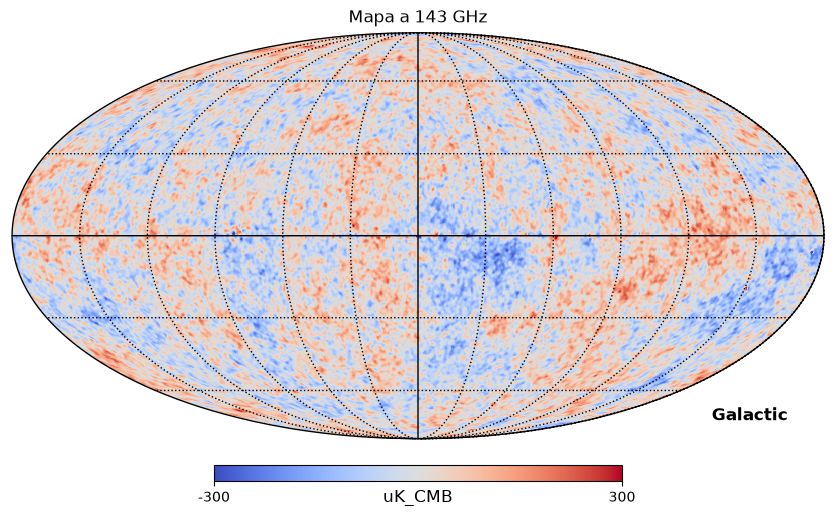

In [4]:
hp.mollview(
    mapa,
    coord="G",
    min=-300,
    max=300,
    cmap="coolwarm",
    title="Mapa a 143 GHz",
    unit="uK_CMB",
)
hp.graticule()
plt.show()

## 4. Verificar a resolução HEALPix

Confirma o NSIDE do mapa original e a relação:

$$N_{pix} = 12\,N_{side}^2$$


In [5]:
nside = hp.get_nside(mapa)
npix = hp.nside2npix(nside)
print(f"NSIDE = {nside}")
print(f"Npix  = 12 x {nside}^2 = {npix:,}")
assert npix == 12 * nside**2

NSIDE = 256
Npix  = 12 x 256^2 = 786,432


## 5. Degradar para NSIDE = 512

`hp.ud_grade` representa o mesmo céu com uma pixelização menos fina. Degradar **não**
muda a região do céu observada, só a resolução da pixelização.


In [6]:
# 512 e o alvo pedido nesta aula. Se o mapa de entrada ja tiver NSIDE menor (caso do
# mapa substituto), reduzimos por um fator 2 em vez de aumentar a resolucao.
NSIDE_ALVO = 512 if nside > 512 else nside // 2

mapa_baixo = hp.ud_grade(mapa, nside_out=NSIDE_ALVO)
npix_baixo = hp.nside2npix(NSIDE_ALVO)

print(f"NSIDE {nside} -> {npix:,} pixels")
print(f"NSIDE {NSIDE_ALVO}  -> {npix_baixo:,} pixels")
print(f"Reducao: {npix / npix_baixo:.1f}x menos pixels")

NSIDE 256 -> 786,432 pixels
NSIDE 128  -> 196,608 pixels
Reducao: 4.0x menos pixels


## 6. Comparar as resoluções

Visualiza as duas resoluções com a mesma escala de cores, depois compara uma pequena
região com `hp.gnomview` — a diferença de detalhe fica mais evidente no zoom do que no
céu inteiro de uma vez.


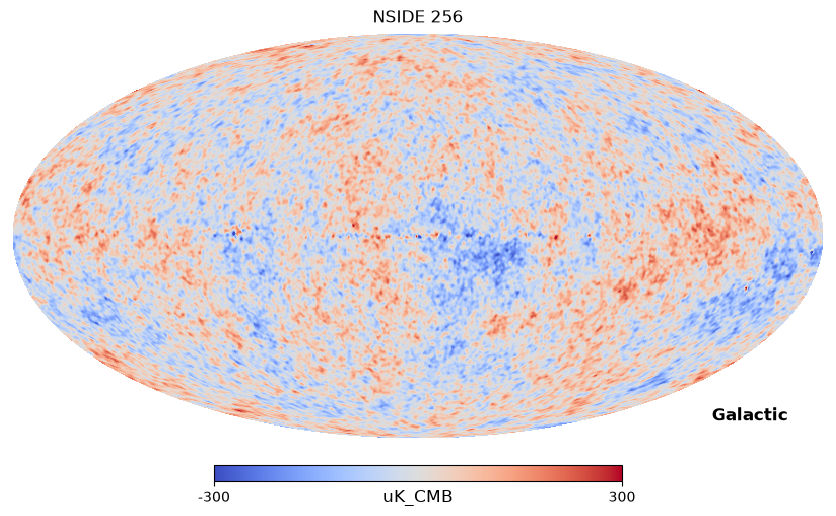

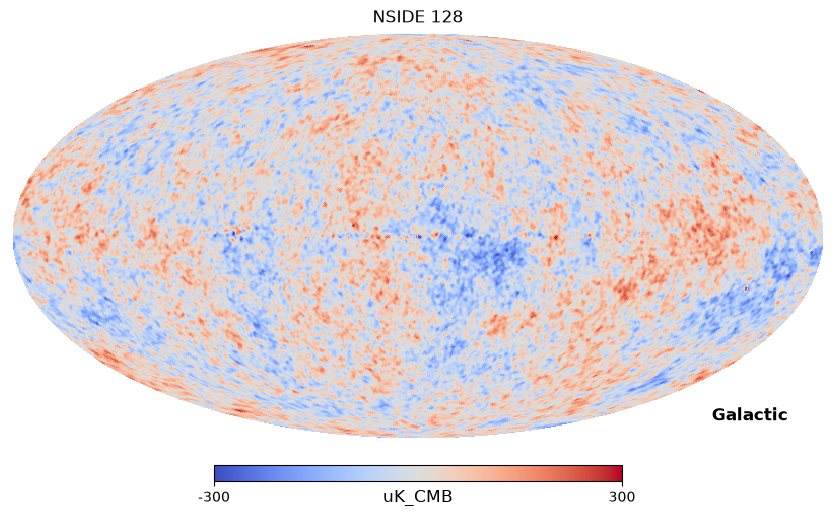

In [7]:
hp.mollview(mapa, coord="G", min=-300, max=300, cmap="coolwarm",
            title=f"NSIDE {nside}", unit="uK_CMB")
plt.show()

hp.mollview(mapa_baixo, coord="G", min=-300, max=300, cmap="coolwarm",
            title=f"NSIDE {NSIDE_ALVO}", unit="uK_CMB")
plt.show()

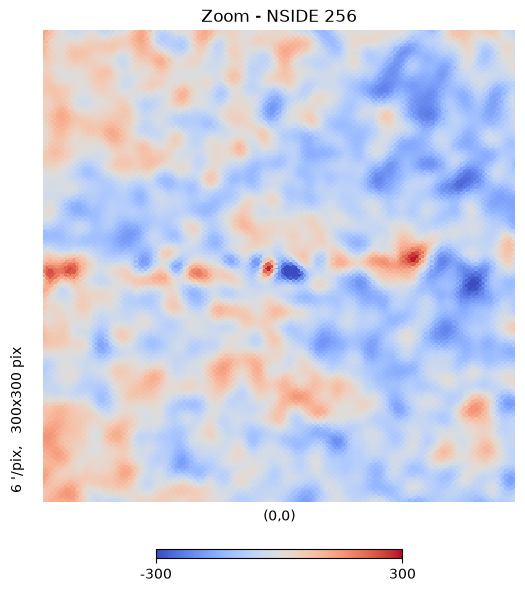

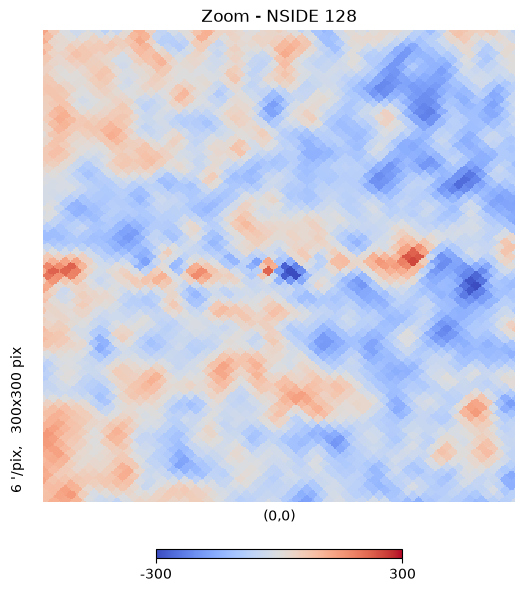

In [8]:
l_zoom, b_zoom = 0.0, 0.0  # direcao do centro galactico

hp.gnomview(mapa, rot=[l_zoom, b_zoom], xsize=300, reso=6, min=-300, max=300,
            cmap="coolwarm", title=f"Zoom - NSIDE {nside}")
plt.show()

hp.gnomview(mapa_baixo, rot=[l_zoom, b_zoom], xsize=300, reso=6, min=-300, max=300,
            cmap="coolwarm", title=f"Zoom - NSIDE {NSIDE_ALVO}")
plt.show()

## 7. Trabalhar com o mapa NSIDE = 512

A partir deste ponto usamos o mapa degradado, para os cálculos ficarem mais leves.
Armazenamos o NSIDE e o número total de pixels.


In [9]:
nside_trabalho = NSIDE_ALVO
npix_trabalho = hp.nside2npix(nside_trabalho)
print(f"Trabalhando com NSIDE={nside_trabalho}, Npix={npix_trabalho:,}")

Trabalhando com NSIDE=128, Npix=196,608


## 8. Relacionar pixels com direções

`hp.pix2ang` converte índice de pixel em ângulos: `theta` (colatitude) e `phi`
(longitude). A latitude galáctica é $b = 90^\circ - \theta$ (em graus, após converter).


In [10]:
pixels = np.arange(npix_trabalho)
theta, phi = hp.pix2ang(nside_trabalho, pixels)

b_lat = 90.0 - np.degrees(theta)  # latitude galactica, em graus

print(f"b varia de {b_lat.min():.1f}° a {b_lat.max():.1f}° (esperado: ~-90 a +90)")

b varia de -89.6° a 89.6° (esperado: ~-90 a +90)


## 9. Construir o corte galáctico

Adotamos inicialmente $|b| < 20°$. O array booleano é `True` para os pixels da região a
excluir (plano galáctico) e `False` para os pixels mantidos. Ver vários `False` no início
não indica erro — a máscara tem um valor para cada pixel.


In [11]:
CORTE_GRAUS = 20
mask_excluir = np.abs(b_lat) < CORTE_GRAUS

print(f"Primeiros 10 valores da mascara: {mask_excluir[:10]}")

Primeiros 10 valores da mascara: [False False False False False False False False False False]


## 10. Conferir a máscara

Conta quantos elementos são `True`, confere o tamanho do array e compara com o número de
pixels do mapa — uma máscara válida tem exatamente um valor booleano por pixel.


In [12]:
n_excluidos = mask_excluir.sum()
print(f"Pixels excluidos (|b| < {CORTE_GRAUS}°): {n_excluidos:,}")
print(f"Tamanho da mascara: {len(mask_excluir):,}")
print(f"Numero de pixels do mapa: {npix_trabalho:,}")
assert len(mask_excluir) == npix_trabalho

Pixels excluidos (|b| < 20°): 67,072
Tamanho da mascara: 196,608
Numero de pixels do mapa: 196,608


## 11. Aplicar a máscara

Copia o mapa e atribui `hp.UNSEEN` aos pixels selecionados pelo corte. **Não** apagamos
elementos do vetor — isso destruiria a correspondência entre índice HEALPix e posição no
céu; o array continua com o mesmo tamanho, só os valores mudam.


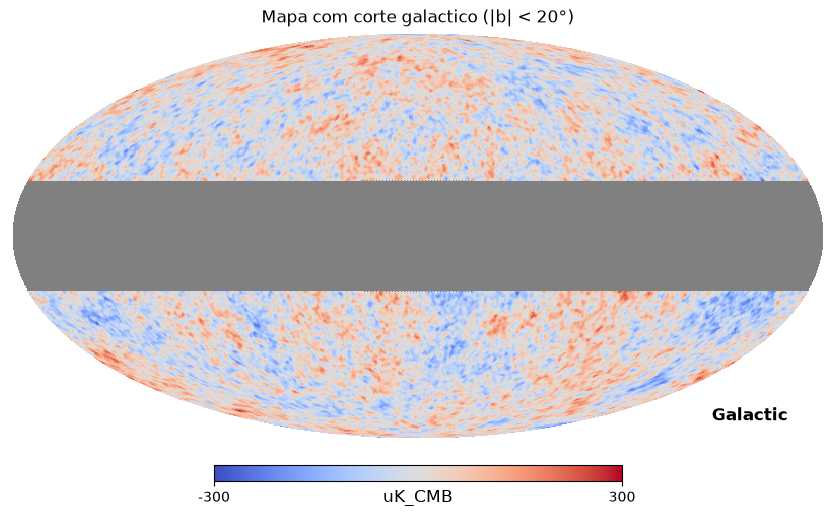

In [13]:
mapa_mask = mapa_baixo.copy()
mapa_mask[mask_excluir] = hp.UNSEEN

hp.mollview(
    mapa_mask,
    coord="G",
    min=-300,
    max=300,
    cmap="coolwarm",
    title=f"Mapa com corte galactico (|b| < {CORTE_GRAUS}°)",
    unit="uK_CMB",
)
plt.show()

## 12. Visualizar a máscara

Mapa binário: **1 para pixels mantidos**, **0 para pixels excluídos**. Visualizado
separadamente do mapa físico de temperatura, para não confundir os dois.


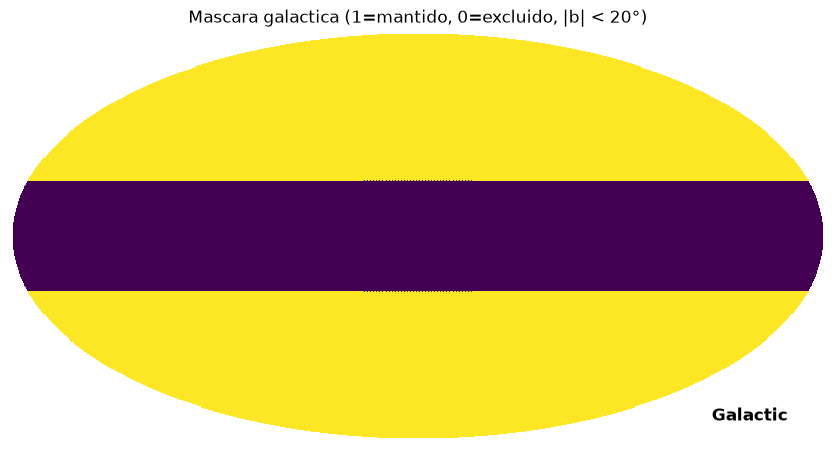

In [14]:
mapa_binario = (~mask_excluir).astype(int)  # 1 = mantido, 0 = excluido

hp.mollview(
    mapa_binario,
    coord="G",
    cmap="viridis",
    title=f"Mascara galactica (1=mantido, 0=excluido, |b| < {CORTE_GRAUS}°)",
    cbar=False,
)
plt.show()

## 13. Calcular f_sky

$$f_{sky} = \frac{N_{pixels\ utilizados}}{N_{pixels\ totais}}$$


In [15]:
f_sky_20 = (~mask_excluir).sum() / npix_trabalho
print(f"f_sky para |b| < {CORTE_GRAUS}°: {f_sky_20:.2f}")

f_sky para |b| < 20°: 0.66


## 14. Comparar cortes

Repete para $|b| < 10°, 20°$ e $30°$: para cada corte, visualiza o mapa e calcula
`f_sky`. Quanto maior o corte, mais céu é removido perto da Galáxia — mas menos céu sobra
para a análise.


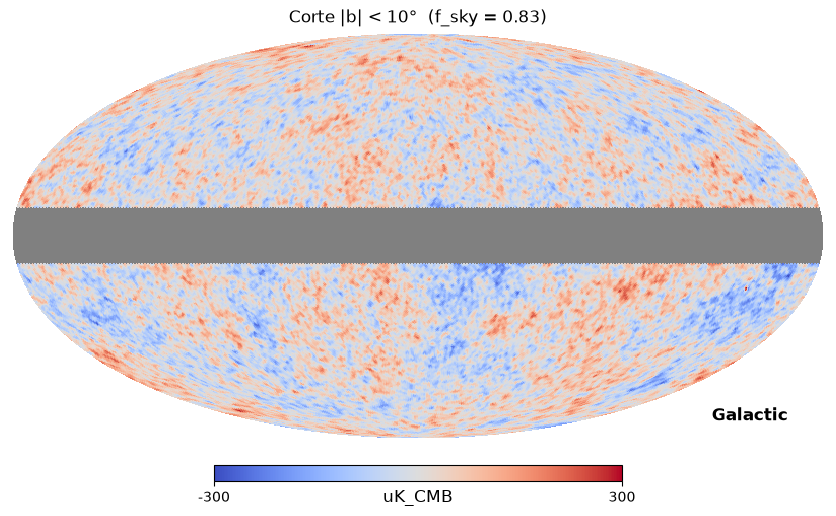

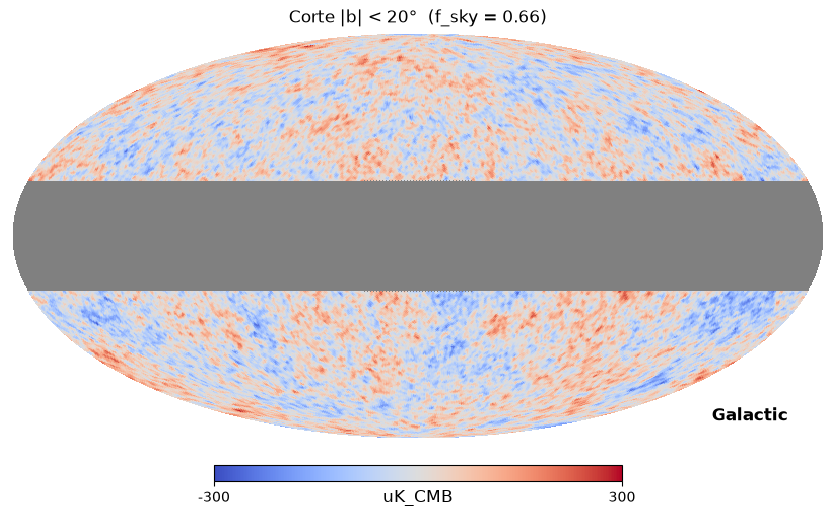

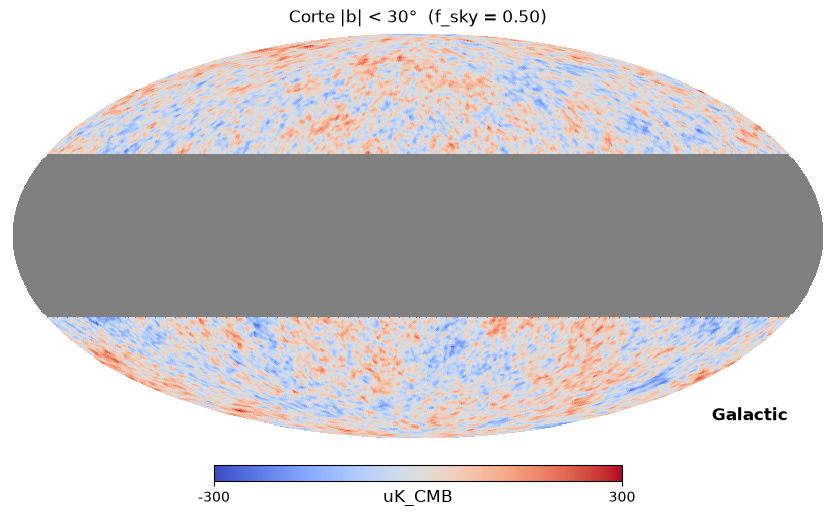

Corte     Regra          f_sky
10°        |b| < 10°       0.83
20°        |b| < 20°       0.66
30°        |b| < 30°       0.50


In [16]:
resultados = []
for corte in (10, 20, 30):
    mask = np.abs(b_lat) < corte
    f_sky = (~mask).sum() / npix_trabalho
    resultados.append((corte, f_sky))

    mapa_corte = mapa_baixo.copy()
    mapa_corte[mask] = hp.UNSEEN
    hp.mollview(mapa_corte, coord="G", min=-300, max=300, cmap="coolwarm",
                title=f"Corte |b| < {corte}°  (f_sky = {f_sky:.2f})", unit="uK_CMB")
    plt.show()

print(f"{'Corte':<10}{'Regra':<15}{'f_sky'}")
for corte, f_sky in resultados:
    print(f"{corte}°{'':<8}|b| < {corte}°{'':<7}{f_sky:.2f}")

## 15. Próximo passo

**Não usamos `anafast` nesta aula.** Uma máscara modifica a relação entre os multipolos;
o espectro obtido de um céu incompleto requer tratamento próprio. Isso será abordado
depois.


## Entregáveis

Mapa original visualizado; NSIDE e N_pix originais; mapa NSIDE 512; comparação das
resoluções; latitude galáctica dos pixels; máscara de 20 graus; mapa binário da máscara;
f_sky; comparação dos cortes de 10, 20 e 30 graus.
